In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<ipython-input-1-b478a6fd18e5>:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
df = pd.read_csv('houseprice.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [4]:
binary_columns = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_columns:
    df[col] = df[col].apply(lambda x: 1 if x == 'yes' else 0)

In [5]:
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

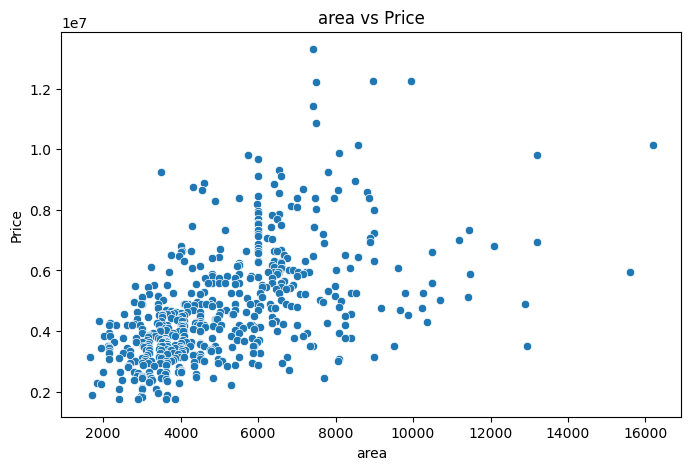

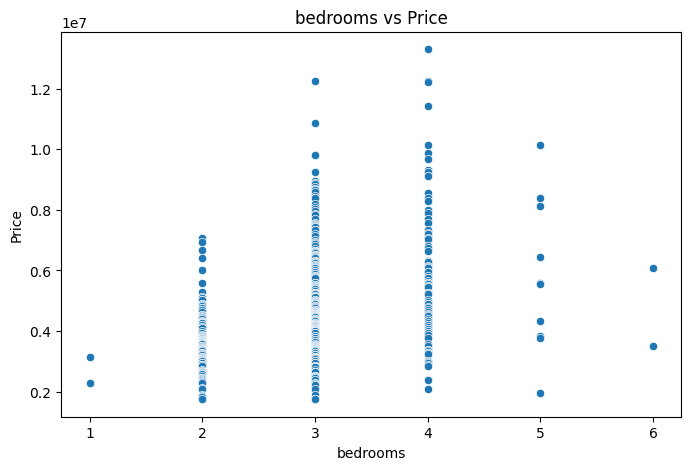

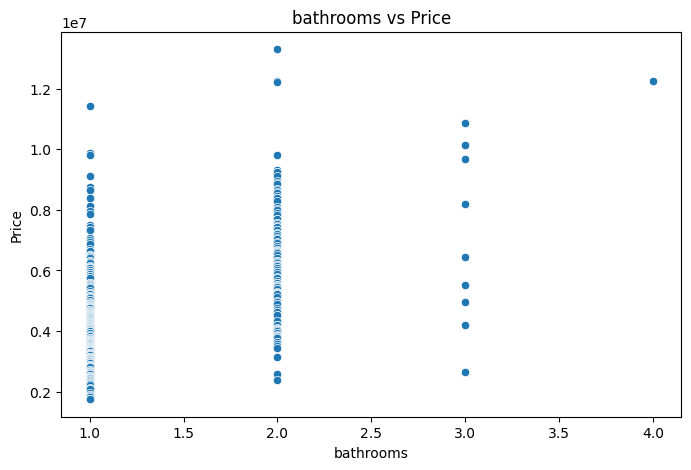

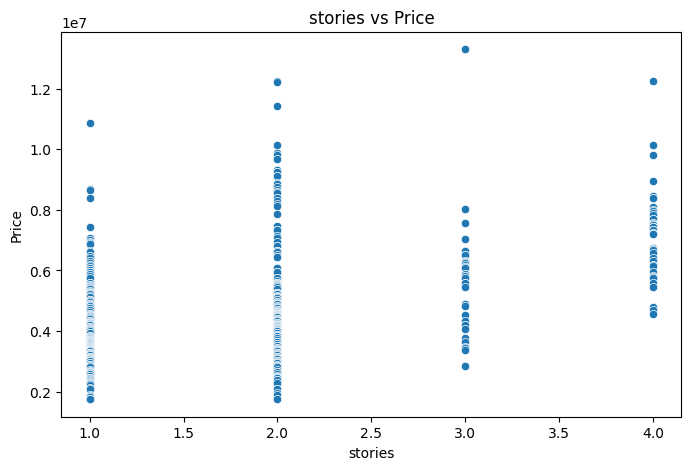

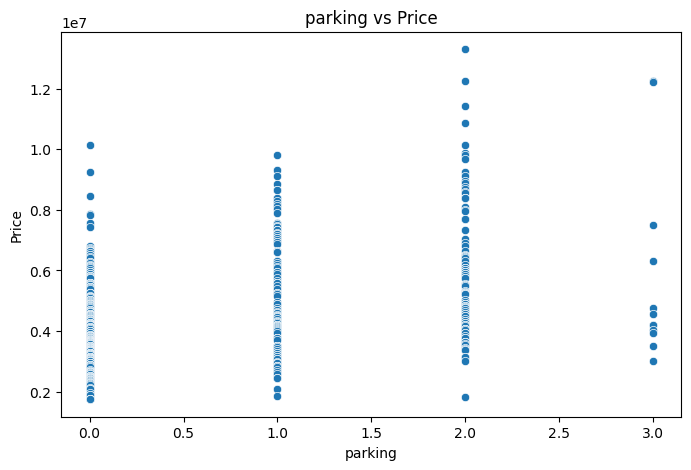

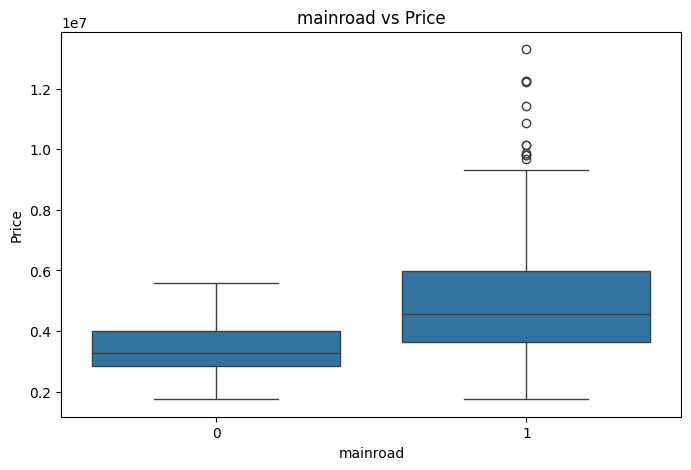

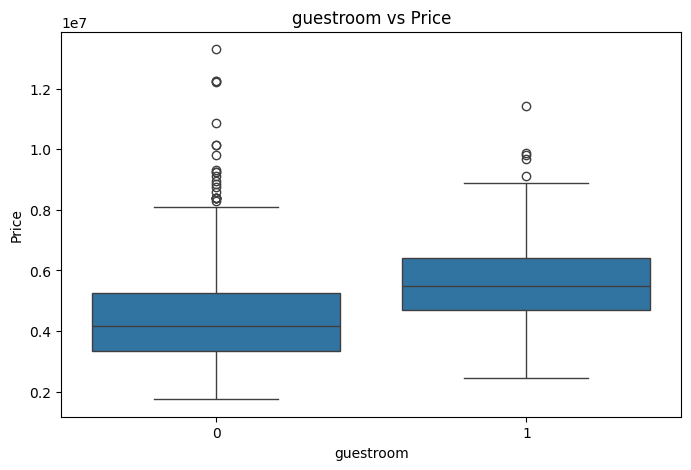

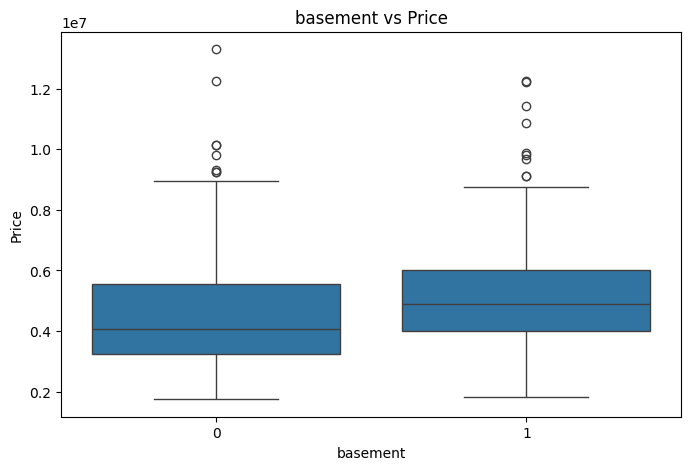

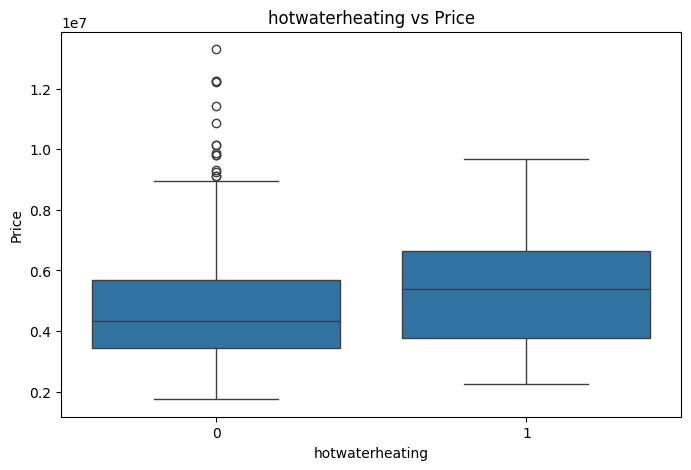

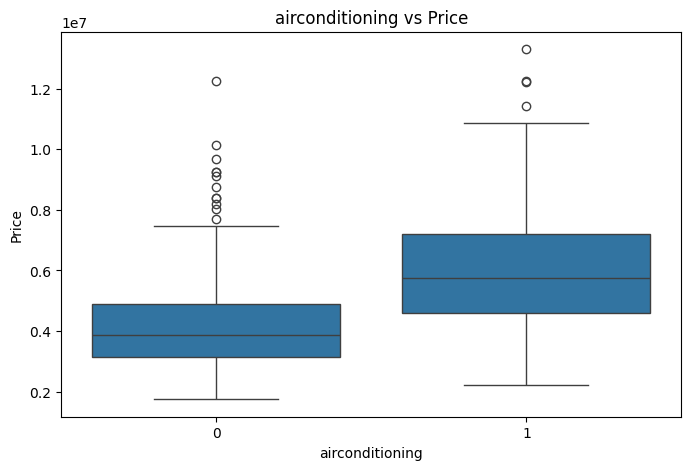

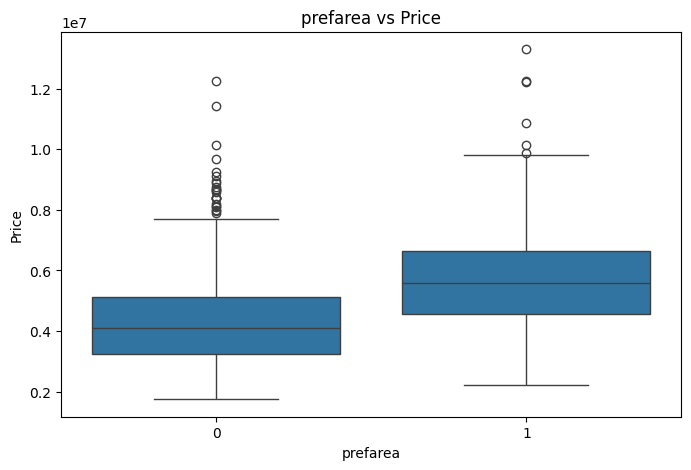

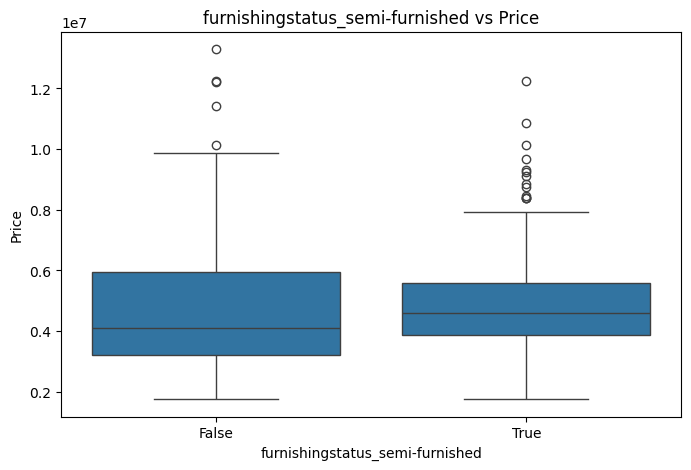

In [6]:
import piplite
await piplite.install('seaborn')
import seaborn as sns
numeric_features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

for feature in numeric_features:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=df[feature], y=df['price'])
    plt.title(f'{feature} vs Price')
    plt.xlabel(feature)
    plt.ylabel('Price')
    plt.show()

categorical_features = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 
                        'airconditioning', 'prefarea', 'furnishingstatus_semi-furnished']

for feature in categorical_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[feature], y=df['price'])
    plt.title(f'{feature} vs Price')
    plt.xlabel(feature)
    plt.ylabel('Price')
    plt.show()

In [7]:
X = df.drop(columns=['price'])
y = df['price']

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler

In [9]:
numerical_columns = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
scaler = MinMaxScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

In [10]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,0.396564,0.6,0.333333,0.666667,1,0,0,0,1,0.666667,1,False,False
1,12250000,0.502405,0.6,1.000000,1.000000,1,0,0,0,1,1.000000,0,False,False
2,12250000,0.571134,0.4,0.333333,0.333333,1,0,1,0,0,0.666667,1,True,False
3,12215000,0.402062,0.6,0.333333,0.333333,1,0,1,0,1,1.000000,1,False,False
4,11410000,0.396564,0.6,0.000000,0.333333,1,1,1,0,1,0.666667,0,False,False


In [11]:
df['furnishingstatus_semi-furnished'] = df['furnishingstatus_semi-furnished'].astype(int)
df['furnishingstatus_unfurnished'] = df['furnishingstatus_unfurnished'].astype(int)

In [12]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,0.396564,0.6,0.333333,0.666667,1,0,0,0,1,0.666667,1,0,0
1,12250000,0.502405,0.6,1.000000,1.000000,1,0,0,0,1,1.000000,0,0,0
2,12250000,0.571134,0.4,0.333333,0.333333,1,0,1,0,0,0.666667,1,1,0
3,12215000,0.402062,0.6,0.333333,0.333333,1,0,1,0,1,1.000000,1,0,0
4,11410000,0.396564,0.6,0.000000,0.333333,1,1,1,0,1,0.666667,0,0,0


In [13]:
X = df.drop(columns=['price'])
y = df['price']

In [14]:
import piplite
await piplite.install('seaborn')

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
X['total_rooms'] = X['bedrooms'] + X['bathrooms']

In [17]:
X.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,total_rooms
0,0.396564,0.6,0.333333,0.666667,1,0,0,0,1,0.666667,1,0,0,0.933333
1,0.502405,0.6,1.000000,1.000000,1,0,0,0,1,1.000000,0,0,0,1.600000
2,0.571134,0.4,0.333333,0.333333,1,0,1,0,0,0.666667,1,1,0,0.733333
3,0.402062,0.6,0.333333,0.333333,1,0,1,0,1,1.000000,1,0,0,0.933333
4,0.396564,0.6,0.000000,0.333333,1,1,1,0,1,0.666667,0,0,0,0.600000


In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [21]:
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae}")
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2}")

Mean Absolute Error (MAE): 970043.4039201642
R² Score: 0.6529242642153176
